Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

# **node2vec**

En esta *notebook*, estaremos trabajando con datos sobre Game of Thrones. Concretamente, el libro *A Storm of Swords*.

### **Creación del grafo**

Los **nodos** serán los **personajes**.

Los **enlaces** representarán la **coaparición** de los dos personajes en cuestión, entendida como la aparición en el texto de sus nombres dentro de un rango de 15 palabras uno del otro.

Los **pesos** serán la cantidad de **veces** que coaparecen.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [21]:
got = nx.Graph() # Creamos una instancia de un grafo.

# Lo completamos en base a los datos.
with open('td6-p11-d-datos-got.csv', 'r') as f:
    for i, line in enumerate(f):
        orig, dest, weight = line.strip().split(',')
        
        if not i:
            continue
        
        got.add_edge(orig, dest,
                     weight = int(weight),
                     inv_weight = 1 / int(weight))

# Lógica detrás de inv_weight = 1 / int(weight)
    # Dado que, en este caso, un alto peso es algo bueno, no malo,
    # inv_weight = 1 / int(weight) para que, ante un alto peso, inv_weigth sea
    # muy chico.

In [22]:
# Calculamos algunas métricas de redes. (No hace falta entrar en detalle en
# ellas. Las calculamos para luego poder visualizar mejor el grafo).

# Average path length (i.e., la longitud promedio de la caminata).
nx.average_shortest_path_length(got, weight = 'inv_weight')

# Betweenness centrality (i.e., la cantidad de caminos más cortos que incluyen
# al nodo en cuestión).
bet_cent = nx.betweenness_centrality(got, weight = 'inv_weight')
for n in bet_cent:
    got.nodes[n]['betweenness_centrality'] = bet_cent[n]

sorted([(node, got.nodes[node]['betweenness_centrality']) for node in got.nodes],
        key = lambda x: x[1],
        reverse = True)

# Closeness centrality (se basa en la idea de que un nodo es central si está a
# poca distancia de todo el resto).
clo_cent = nx.closeness_centrality(got, distance = 'inv_weight')
for n in clo_cent:
    got.nodes[n]['closeness_centrality'] = clo_cent[n]

sorted([(node, got.nodes[node]['closeness_centrality']) for node in got.nodes],
        key = lambda x: x[1],
        reverse = True)

# Pagerank centrality (i.e., la probabilidad de que en un momento cualquiera de
# la caminata uno esté parado en el nodo en cuestión; captura idea que si un
# nodo popular me apunta a mí entonces yo también soy popular).
pr_cent = nx.pagerank(got, weight = 'weight') # Ojo que acá hay que usar weight, en vez de inv_weight.
for n in pr_cent:
    got.nodes[n]['page_rank'] = pr_cent[n]

sorted([(node, got.nodes[node]['page_rank']) for node in got.nodes],
        key = lambda x: x[1],
        reverse = True)

# Modularidad (i.e., la calidad de la división del grafo).
# !pip install -U python-louvain
import community.community_louvain as cl
partition = cl.best_partition(got, weight = 'weight')
for n in partition:
    got.nodes[n]['community'] = partition[n]

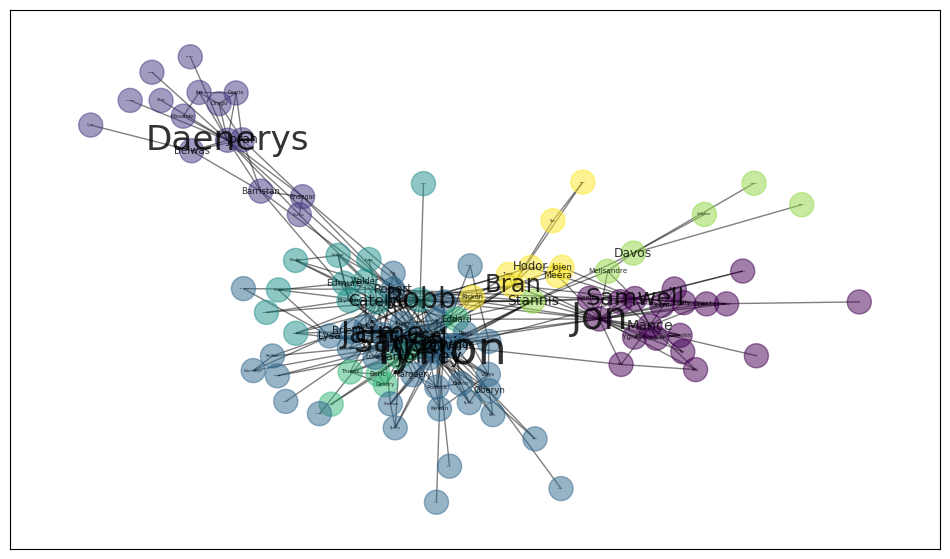

In [37]:
# Lo visualizamos.
pos = nx.spring_layout(got,
                       k = 0.25,
                       weight = 'weight')
plt.figure(figsize = (12, 7))
nx.draw_networkx(got,
                 pos = pos,
                 with_labels = False,
                 node_color = [partition[k] for k in pr_cent],
                 alpha = 0.5)
for node, (x, y) in pos.items():
    plt.text(x, y, node,
             fontsize = 600 * pr_cent[node],
             ha = 'center',
             va = 'center',
             alpha = 0.8)
plt.show()

### **Ahora sí, node2vec**

In [38]:
# !pip install -U node2vec
from node2vec import Node2Vec

# !pip install -U pacmap
import pacmap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 270.0 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for fst-pso: filename=fst_pso-1.8.1-py3-none-any.whl size=20430 sha256=82af68c5f8fc88903b49f099c0e1b4eddb24bf8c4dc766b294e0f1a8bebdc01c
  Stored in directory: /Users/chiaracalviellocrusella/Library/Caches/pip/wheels/99/66/48/d7ce0c6927f6abf167bbcdee537affc7b92c03632f78028411
  Created wheel for miniful: filename=miniful-0.0.6-py3-none-any.whl size=3513 sha256=84236f28c9180debcd11b3de6796d9a06f7bcad9f1d5b999fed0b09198a4659d
  Stored in directory: /Users/chiaracalviellocrusella/Library/Caches/pip/wheels/d9/c7/71/db1d4646d963b34c530667501d3d6f34c0825eaffae2f0f2cb
Successfully built fst-pso miniful
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 1.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp39-cp39-macosx_10_12_x86_64.

In [75]:
# Generamos las caminatas.
got_vectors = Node2Vec(got,
                       dimensions = 64,
                       walk_length = 40,
                       num_walks = 128,
                       p = 0.3,
                       q = 0.1,
                       workers = 4, # Número de trabajadores para ejecución en paralelo.
                       seed = 13579)
# Documentación oficial: https://github.com/eliorc/node2vec

# Entrenamos el modelo.
got_model = got_vectors.fit(window = 5,
                            min_count = 1)

Computing transition probabilities:   0%|          | 0/107 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 32/32 [00:00<00:00, 69.36it/s]


In [76]:
got_model.wv.most_similar('Jon')

[('Qhorin', 0.8939852118492126),
 ('Mance', 0.8826106190681458),
 ('Rattleshirt', 0.8770272731781006),
 ('Ygritte', 0.8723238110542297),
 ('Styr', 0.8277063369750977),
 ('Orell', 0.7732095718383789),
 ('Aemon', 0.7269353270530701),
 ('Alliser', 0.7244676947593689),
 ('Dalla', 0.719066321849823),
 ('Samwell', 0.713616669178009)]

In [77]:
got_model.wv.most_similar('Arya')

[('Gendry', 0.7228429913520813),
 ('Sandor', 0.6939743757247925),
 ('Beric', 0.6895300149917603),
 ('Anguy', 0.6876273155212402),
 ('Thoros', 0.666506826877594),
 ('Eddard', 0.6401247978210449),
 ('Roose', 0.5680346488952637),
 ('Rickon', 0.49611613154411316),
 ('Brynden', 0.48352381587028503),
 ('Meryn', 0.46473509073257446)]

In [78]:
got_model.wv.most_similar('Catelyn')

[('Walder', 0.7956323623657227),
 ('Robb', 0.7571581602096558),
 ('Lothar', 0.7528670430183411),
 ('Roslin', 0.7184047102928162),
 ('Edmure', 0.717045783996582),
 ('Jeyne', 0.6975831985473633),
 ('Brynden', 0.6640384197235107),
 ('Rickard', 0.6518359184265137),
 ('Ramsay', 0.6382051706314087),
 ('Petyr', 0.636290967464447)]

In [79]:
got_model.wv.most_similar('Daenerys')

[('Daario', 0.9275861978530884),
 ('Kraznys', 0.9260631799697876),
 ('Drogo', 0.9218892455101013),
 ('Jorah', 0.9188790321350098),
 ('Rakharo', 0.9132123589515686),
 ('Missandei', 0.9119147062301636),
 ('Worm', 0.90577632188797),
 ('Aegon', 0.9003687500953674),
 ('Irri', 0.8979611992835999),
 ('Belwas', 0.8665028214454651)]

In [80]:
vocab = list(got_model.wv.index_to_key)

embedding = pacmap.PaCMAP(n_components = 2,
                          n_neighbors = None,
                          MN_ratio = 0.5,
                          FP_ratio = 2.0
                         ).fit_transform(got_model.wv.get_normed_vectors())
# https://pypi.org/project/pacmap/

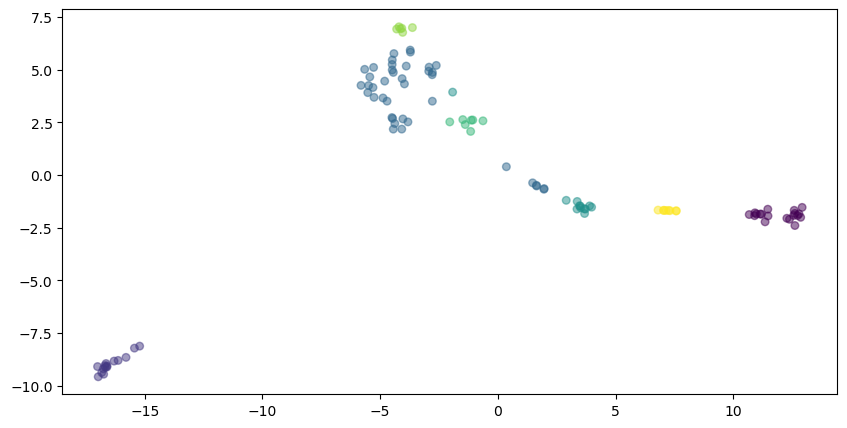

In [81]:
plt.figure(figsize = (10, 5))
plt.scatter(embedding[:, 0],
            embedding[:, 1],
            s = 30,
            c = [partition[n] for n in vocab],
            alpha = 0.5)
plt.show()